<a href="https://colab.research.google.com/github/sarahayek98/Alzheimer-detection-using-3-machine-learning-algorithms-/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -U scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your folder
folder_name = 'AlzheimerDataset'
folder_path = f'/content/drive/MyDrive/{folder_name}'

# List files in the folder
files = os.listdir(folder_path)
print(files)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test', 'train']


In [4]:
# Import necessary libraries
import numpy as np
import os
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix , classification_report

In [5]:
train_folder = '/content/drive/MyDrive/AlzheimerDataset/train'
test_folder = '/content/drive/MyDrive/AlzheimerDataset/test'

In [6]:
def preprocess_image(image_path, target_size=(64, 64)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    image = cv2.resize(image, target_size)  # Resize image
    image = image / 255.0  # Normalize pixel values
    return image

In [7]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for subfolder in os.listdir(folder):
        subfolder_path = os.path.join(folder, subfolder)
        for filename in os.listdir(subfolder_path):
            img_path = os.path.join(subfolder_path, filename)
            image = preprocess_image(img_path)
            images.append(image)
            labels.append(subfolder)
    return np.array(images), np.array(labels)

In [8]:
X_train, y_train = load_images_from_folder(train_folder)
X_test, y_test = load_images_from_folder(test_folder)

In [9]:
#Model Training
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # Flatten the image arrays
rf_classifier.fit(X_train_flattened, y_train)

RandomForestClassifier(random_state=42)

In [10]:
#  Model Evaluation
X_test_flattened = X_test.reshape(X_test.shape[0], -1)  # Flatten the image arrays
y_pred = rf_classifier.predict(X_test_flattened)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [11]:
print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6293979671618452
Recall: 0.6293979671618452
F1 Score: 0.5940587797378093


In [13]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt  # Import Matplotlib
import seaborn as sns
import numpy as np

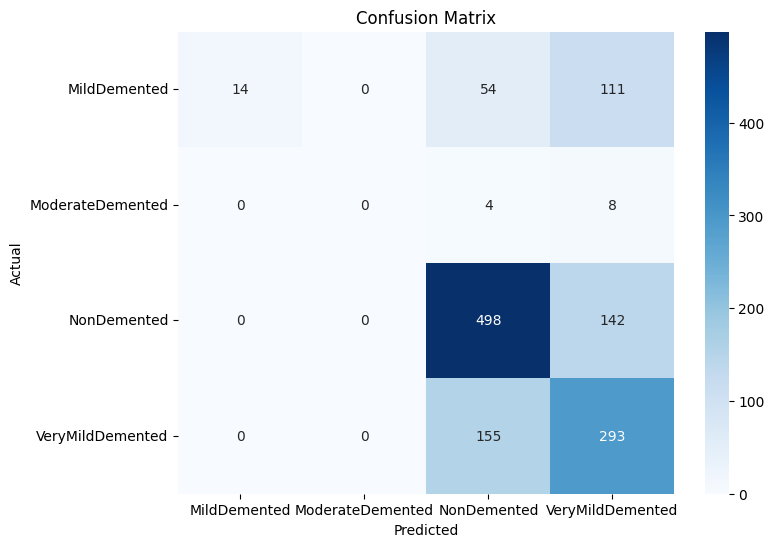

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()